# Permeability via LBM flow solver

This example computes the absolute permeability of a synthetic porous medium using the D3Q19 MRT lattice Boltzmann solver.

In [1]:
import porespy as ps
import matplotlib.pyplot as plt
import poromics

## Generate a porous medium image

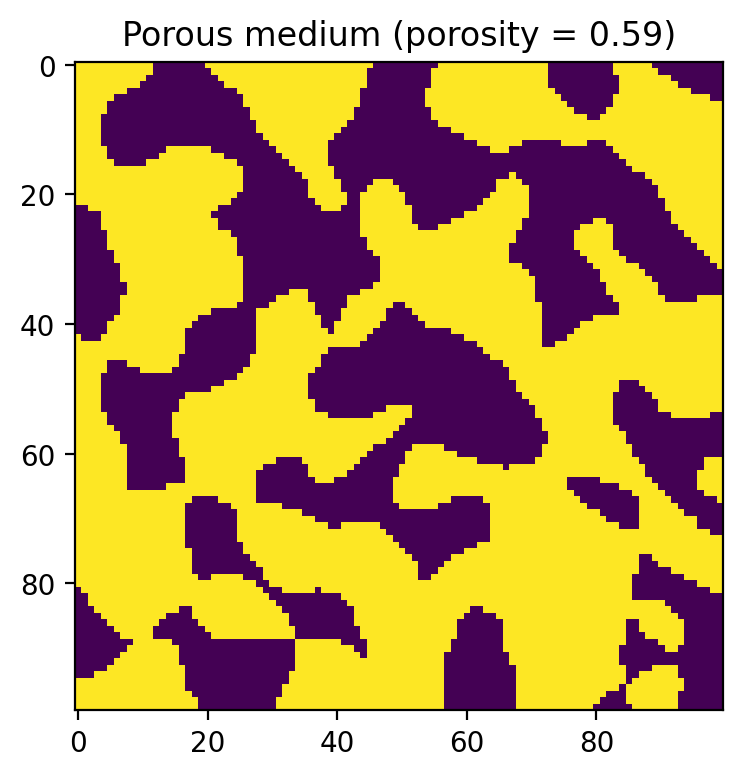

In [2]:
im = ps.generators.blobs(shape=[100, 100, 1], porosity=0.6, blobiness=0.5, seed=42)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(im[:, :, 0], cmap="viridis", interpolation="nearest")
ax.set_title(f"Porous medium (porosity = {im.mean():.2f})")
plt.tight_layout()

## Compute permeability

We use a kinematic viscosity of $10^{-6}$ m²/s (water at ~20 °C) and a voxel size of 1 µm.

In [3]:
result = poromics.permeability_lbm(im, axis=1, nu=1e-6, voxel_size=1e-6)
print(result)
print(f"Permeability: {result.k_m2:.4e} m² ({result.k_mD:.2f} mD)")
print(f"Darcy velocity: {result.u_darcy:.4e} m/s")
print(f"Pore velocity: {result.u_pore:.4e} m/s")

2026-03-09 01:26:03.04 | WARNING  | poromics._metrics:permeability_lbm:631 - Trimmed 972 non-percolating pore voxels from the image.
[I 03/09/26 01:26:03.167 22015666] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.12.9


[Taichi] Starting on arch=metal


Flow:   0%|          | 0.0% ·  · 00:00

PermeabilityResult(k_m2=2.826718e-13, k_mD=286.4172, axis=1)
Permeability: 2.8267e-13 m² (286.42 mD)
Darcy velocity: 3.3921e-04 m/s
Pore velocity: 6.8513e-04 m/s


## Visualize the velocity field

Since our image is quasi-2D (shape 100×100×1), we can visualize the velocity as streamlines on the z=0 slice.

(<Figure size 750x400 with 4 Axes>,
 array([<Axes: title={'center': 'Velocity magnitude'}>,
        <Axes: title={'center': 'Velocity streamlines'}>], dtype=object))

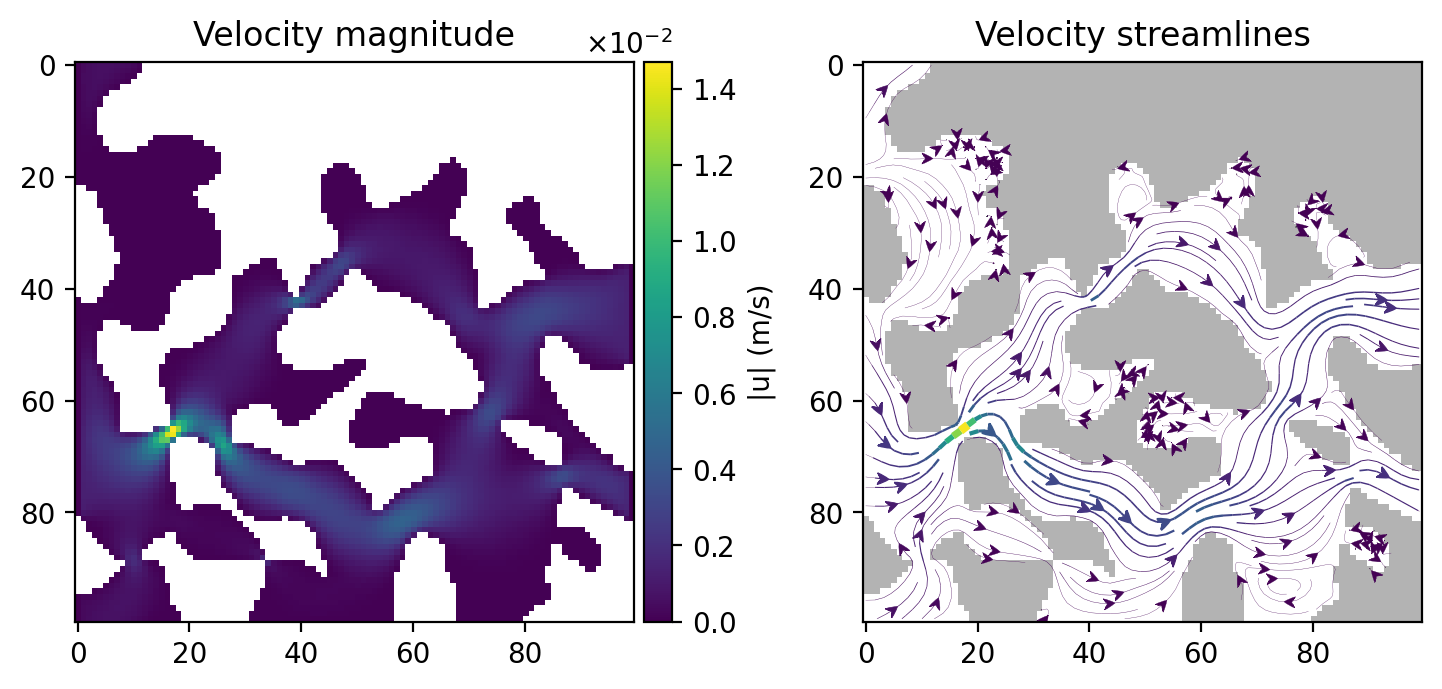

In [4]:
result.plot_velocity(z=0)

## Using the low-level solver

For more control, use `TransientFlow` directly.

In [5]:
from poromics.simulation import TransientFlow

solver = TransientFlow(im, axis=1, nu=1e-6, voxel_size=1e-6)
solver.run(n_steps=50_000, tol=1e-3)

print(f"Converged: {solver.converged}")
print(f"Iterations: {solver.n_iterations}")
print(f"Physical time step: {solver.dt:.2e} s")

Converged: True
Iterations: 6001
Physical time step: 1.67e-07 s


## Visualize the pressure field

The result object also stores the gauge pressure field:

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'Pressure field (Pa)'}>)

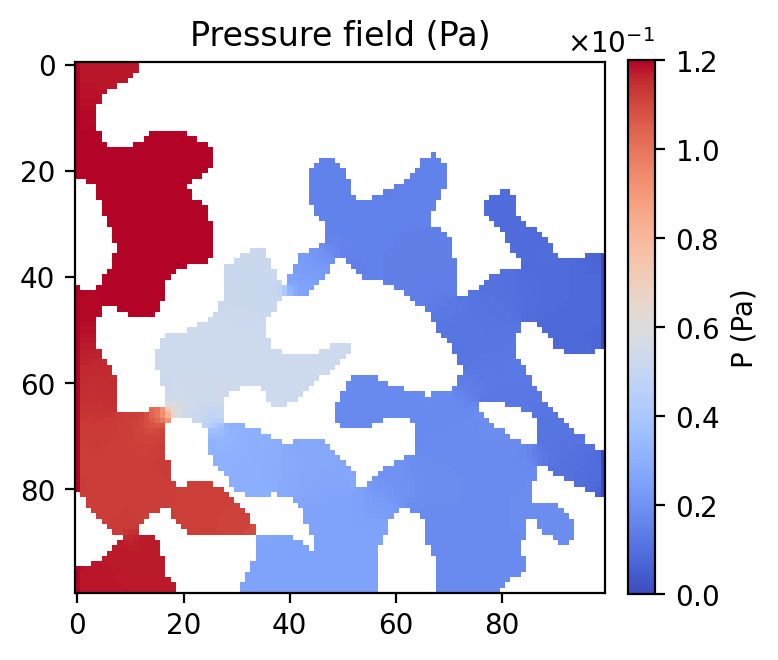

In [6]:
result.plot_pressure(z=0)